# Load datasets

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/data-crunch-round-1/sample_submission.csv
/kaggle/input/data-crunch-round-1/train.csv
/kaggle/input/data-crunch-round-1/test.csv


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

In [3]:
data = pd.read_csv('/kaggle/input/data-crunch-round-1/train.csv')

# Initial Data Inspection

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84960 entries, 0 to 84959
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            84960 non-null  int64  
 1   Year                          84960 non-null  int64  
 2   Month                         84960 non-null  int64  
 3   Day                           84960 non-null  int64  
 4   kingdom                       84960 non-null  object 
 5   latitude                      84960 non-null  float64
 6   longitude                     84960 non-null  float64
 7   Avg_Temperature               84960 non-null  float64
 8   Avg_Feels_Like_Temperature    84960 non-null  float64
 9   Temperature_Range             84960 non-null  float64
 10  Feels_Like_Temperature_Range  84960 non-null  float64
 11  Radiation                     84960 non-null  float64
 12  Rain_Amount                   84960 non-null  float64
 13  R

In [5]:
print(data.describe())

                 ID          Year         Month           Day      latitude  \
count  84960.000000  84960.000000  84960.000000  84960.000000  84960.000000   
mean   42480.500000      4.610876      6.666667     15.735876     24.003334   
std    24525.983772      2.239331      3.402793      8.802867      0.798622   
min        1.000000      1.000000      1.000000      1.000000     22.880000   
25%    21240.750000      3.000000      4.000000      8.000000     23.680003   
50%    42480.500000      5.000000      7.000000     16.000000     23.780002   
75%    63720.250000      7.000000     10.000000     23.000000     24.280002   
max    84960.000000      8.000000     12.000000     31.000000     26.580005   

          longitude  Avg_Temperature  Avg_Feels_Like_Temperature  \
count  84960.000000     84960.000000                84960.000000   
mean     -37.266665       135.600751                  139.735375   
std        0.488873       133.650417                  133.937168   
min      -37.729

In [6]:
print(data.isnull().sum())  # Check missing values

ID                              0
Year                            0
Month                           0
Day                             0
kingdom                         0
latitude                        0
longitude                       0
Avg_Temperature                 0
Avg_Feels_Like_Temperature      0
Temperature_Range               0
Feels_Like_Temperature_Range    0
Radiation                       0
Rain_Amount                     0
Rain_Duration                   0
Wind_Speed                      0
Wind_Direction                  0
Evapotranspiration              0
dtype: int64


**There are no any missing values**

In [7]:
print(data.duplicated().sum())  # Check duplicates

0


**There are no any duplicates**

**Drop Unnecessary Columns**

In [8]:
data = data.drop(columns=['ID'])  # Unique ID not needed

# Exploratory Data Analysis

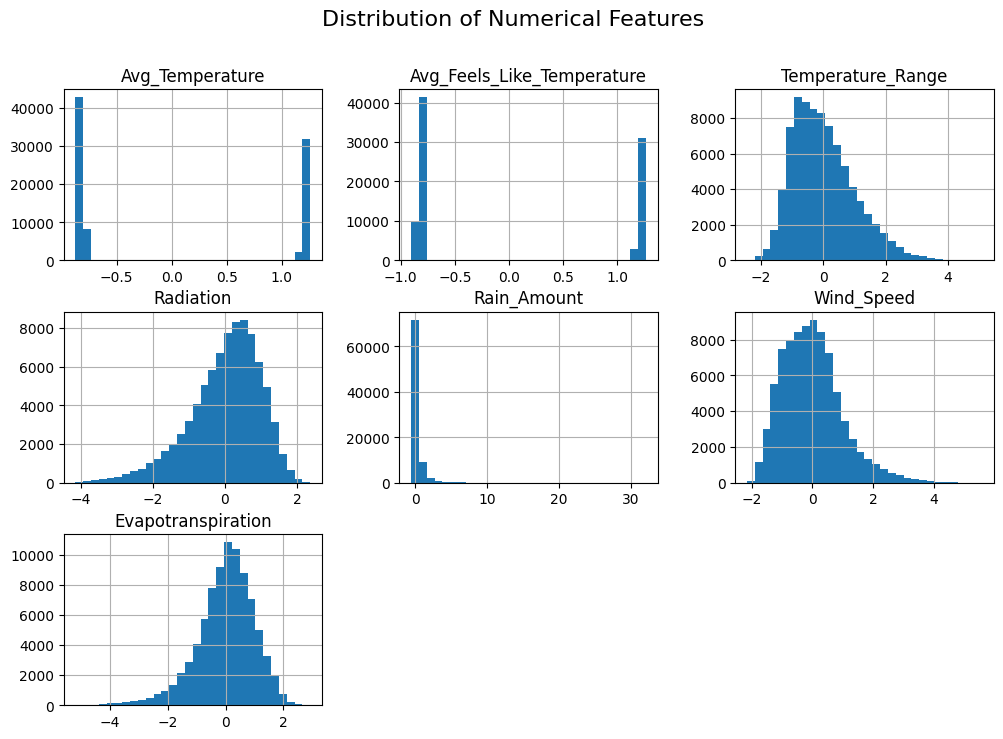

In [9]:
# Select numerical columns
numeric_cols = ["Avg_Temperature", "Avg_Feels_Like_Temperature", "Temperature_Range", 
                "Radiation", "Rain_Amount", "Wind_Speed", "Evapotranspiration"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Plot histograms
data[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


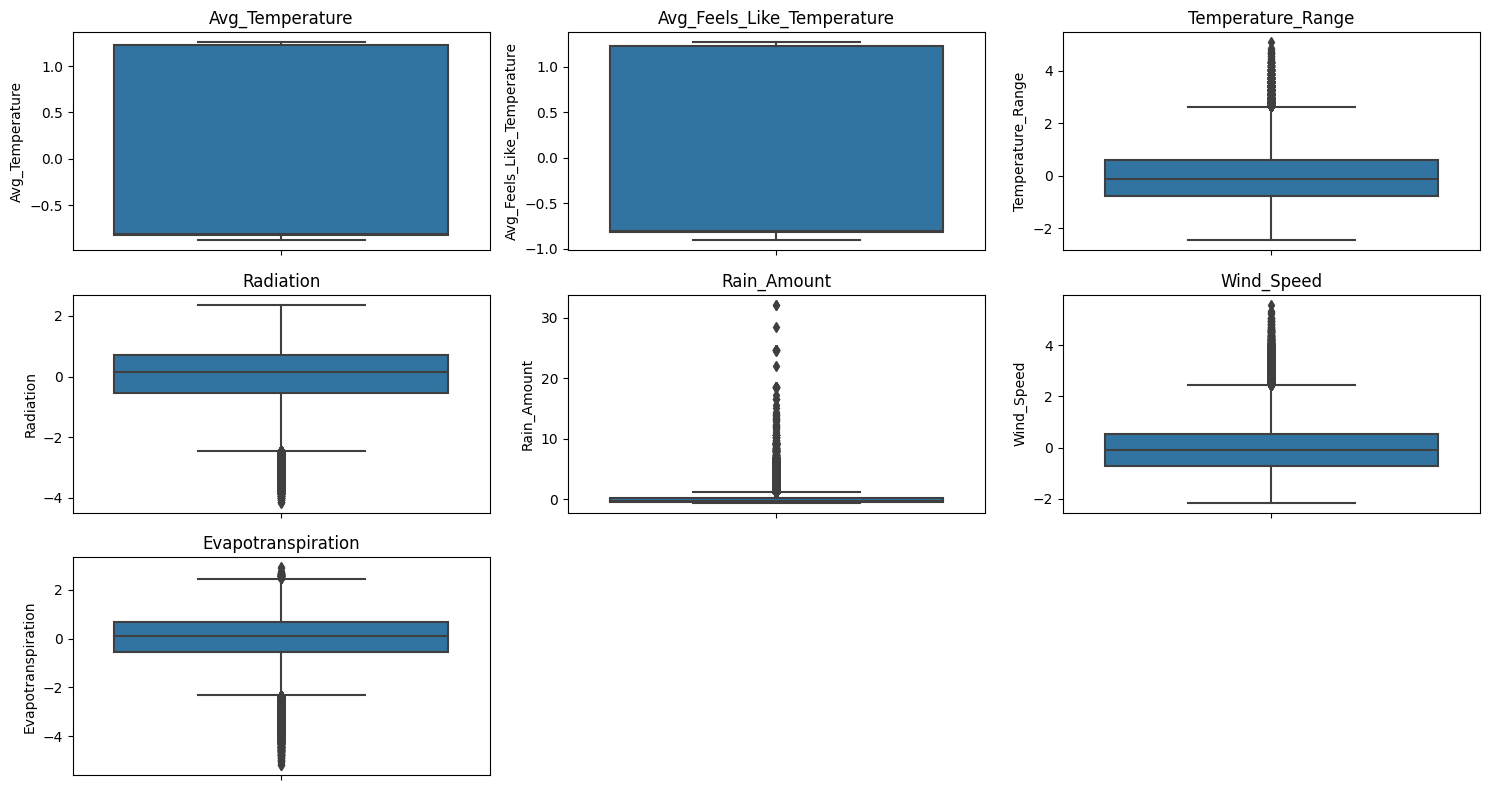

In [10]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Data Preprocessing

**Convert Date to Datetime & Extract Time Features**

In [11]:
#  Adjust the Year column
data['Year'] = data['Year'] + 2000  # Convert from [1,2,3,...] to [2001,2002,...]

# Identify invalid February 29th entries
invalid_feb29 = (data['Month'] == 2) & (data['Day'] == 29) & \
                (~((data['Year'] % 4 == 0) & ((data['Year'] % 100 != 0) | (data['Year'] % 400 == 0))))

# Adjust invalid Feb 29th years to the closest past leap year
data.loc[invalid_feb29, 'Year'] -= (data.loc[invalid_feb29, 'Year'] % 4)  # Adjust to last multiple of 4

# Convert to datetime
data['Date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])

# Print confirmation
print("Date conversion successful!")
print(data[['Year', 'Month', 'Day', 'Date']].head())

Date conversion successful!
   Year  Month  Day       Date
0  2001      4    1 2001-04-01
1  2001      4    1 2001-04-01
2  2001      4    1 2001-04-01
3  2001      4    1 2001-04-01
4  2001      4    1 2001-04-01


**Encode Categorical Features**

In [12]:
# One-hot encode 'kingdom'
kingdom_encoded = pd.get_dummies(data['kingdom'], prefix='kingdom')

# Drop original 'kingdom' column
data = data.drop(columns=['kingdom'])

# Add one-hot encoded columns to dataset
data = pd.concat([data, kingdom_encoded], axis=1)

**Handle Temperature (Convert Kelvin to Celsius**)

In [13]:
temp_cols = ['Avg_Temperature', 'Avg_Feels_Like_Temperature']

for col in temp_cols:
    data[col] = data[col].apply(lambda x: x - 273.15 if (x > 100) else x)

**Log Transformation for Skewed Rain Amount**

In [14]:
# Create a new column with log-transformed rain amount
data['Rain_Amount'] = data['Rain_Amount'].clip(lower=0.01)  # Avoid log(0)
data['Rain_Amount_log'] = np.log1p(data['Rain_Amount'])

**Rain Classification & Encoding**

In [15]:
# Classification based on rain amount
def classify_rain(mm):
    if mm == 0:
        return 'No Rain'
    elif mm <= 2.5:
        return 'Light'
    elif mm <= 10:
        return 'Moderate'
    else:
        return 'Heavy'

# Apply the classifier
data['Rain_Class'] = data['Rain_Amount'].apply(classify_rain)

#  Encode as numbers (ordinal)
rain_mapping = {
    'No Rain': 0,
    'Light': 1,
    'Moderate': 2,
    'Heavy': 3
}

data['Rain_Class_Encoded'] = data['Rain_Class'].map(rain_mapping)

data = data.drop(columns=['Rain_Class'])

# Feature Engineering

**Feature Scaling for Numerical Variables**

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scale_cols = ['Radiation', 'Temperature_Range', 'Evapotranspiration']
data[scale_cols] = scaler.fit_transform(data[scale_cols])

**Wind Speed: Convert Direction to Components (u, v)**

In [17]:
# Convert degrees to radians
data['Wind_Direction_rad'] = np.radians(data['Wind_Direction'])

# Calculate u and v components
data['Wind_u'] = data['Wind_Speed'] * np.cos(data['Wind_Direction_rad'])
data['Wind_v'] = data['Wind_Speed'] * np.sin(data['Wind_Direction_rad'])

# Drop intermediate if you like
data.drop(columns=['Wind_Direction_rad'], inplace=True)

**Geospatial Clustering (Weather Zone)**

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # Explicitly set n_init
data['Weather_Cluster'] = kmeans.fit_predict(data[['latitude', 'longitude']])

**Anomaly Detection (Weather Anomalies)**

In [19]:
iso_forest = IsolationForest(contamination=0.01, random_state=42)
data['Weather_Anomaly'] = iso_forest.fit_predict(data[['Avg_Temperature', 'Rain_Amount', 'Wind_Speed']].to_numpy())

**Create Lag Features (for Time Series Forecasting)**

In [20]:
lagged_features = ['Avg_Temperature', 'Rain_Amount', 'Radiation']

# Create lag features
for lag in [1, 3, 7, 14, 30]:  # 1-day, 3-day, weekly, bi-weekly, monthly lags
    for col in lagged_features:
        data[f"{col}_lag{lag}"] = data[col].shift(lag)

# Create rolling statistics (mean and std)
for col in lagged_features:
    data[f"{col}_rolling_mean7"] = data[col].rolling(window=7).mean()
    data[f"{col}_rolling_std7"] = data[col].rolling(window=7).std()

# Ensure rolling mean does not have NaN by filling it properly
data['Avg_Temperature_rolling_mean7'] = data['Avg_Temperature_rolling_mean7'].fillna(
    data['Avg_Temperature'].expanding().mean()
)

data['Rain_Amount_rolling_mean7'] = data['Rain_Amount_rolling_mean7'].fillna(
    data['Rain_Amount'].expanding().mean()
)

data['Radiation_rolling_mean7'] = data['Radiation_rolling_mean7'].fillna(
    data['Radiation'].expanding().mean()
)

# Ensure rolling std does not have NaN by filling it with 0 (as std is undefined at small samples)
data['Avg_Temperature_rolling_std7'] = data['Avg_Temperature_rolling_std7'].fillna(0)
data['Rain_Amount_rolling_std7'] = data['Rain_Amount_rolling_std7'].fillna(0)
data['Radiation_rolling_std7'] = data['Radiation_rolling_std7'].fillna(0)

# Print to check if any NaN values remain
print("NaN values after filling missing rolling features:")
print(data.isna().sum())


NaN values after filling missing rolling features:
Year                            0
Month                           0
Day                             0
latitude                        0
longitude                       0
                               ..
Avg_Temperature_rolling_std7    0
Rain_Amount_rolling_mean7       0
Rain_Amount_rolling_std7        0
Radiation_rolling_mean7         0
Radiation_rolling_std7          0
Length: 73, dtype: int64


**Fourier Features (Seasonality)**

In [21]:
# Ensure 'Date' column exists
data['Date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])

# Compute 'Day_of_Year'
data['Day_of_Year'] = data['Date'].dt.dayofyear

# Apply cyclic encoding for seasonality
data['Month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['Month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)
data['Day_of_Year_sin'] = np.sin(2 * np.pi * data['Day_of_Year'] / 365)
data['Day_of_Year_cos'] = np.cos(2 * np.pi * data['Day_of_Year'] / 365)

print(data[['Date', 'Day_of_Year', 'Month_sin', 'Month_cos', 'Day_of_Year_sin', 'Day_of_Year_cos']].head())

        Date  Day_of_Year  Month_sin  Month_cos  Day_of_Year_sin  \
0 2001-04-01           91   0.866025       -0.5         0.999991   
1 2001-04-01           91   0.866025       -0.5         0.999991   
2 2001-04-01           91   0.866025       -0.5         0.999991   
3 2001-04-01           91   0.866025       -0.5         0.999991   
4 2001-04-01           91   0.866025       -0.5         0.999991   

   Day_of_Year_cos  
0         0.004304  
1         0.004304  
2         0.004304  
3         0.004304  
4         0.004304  


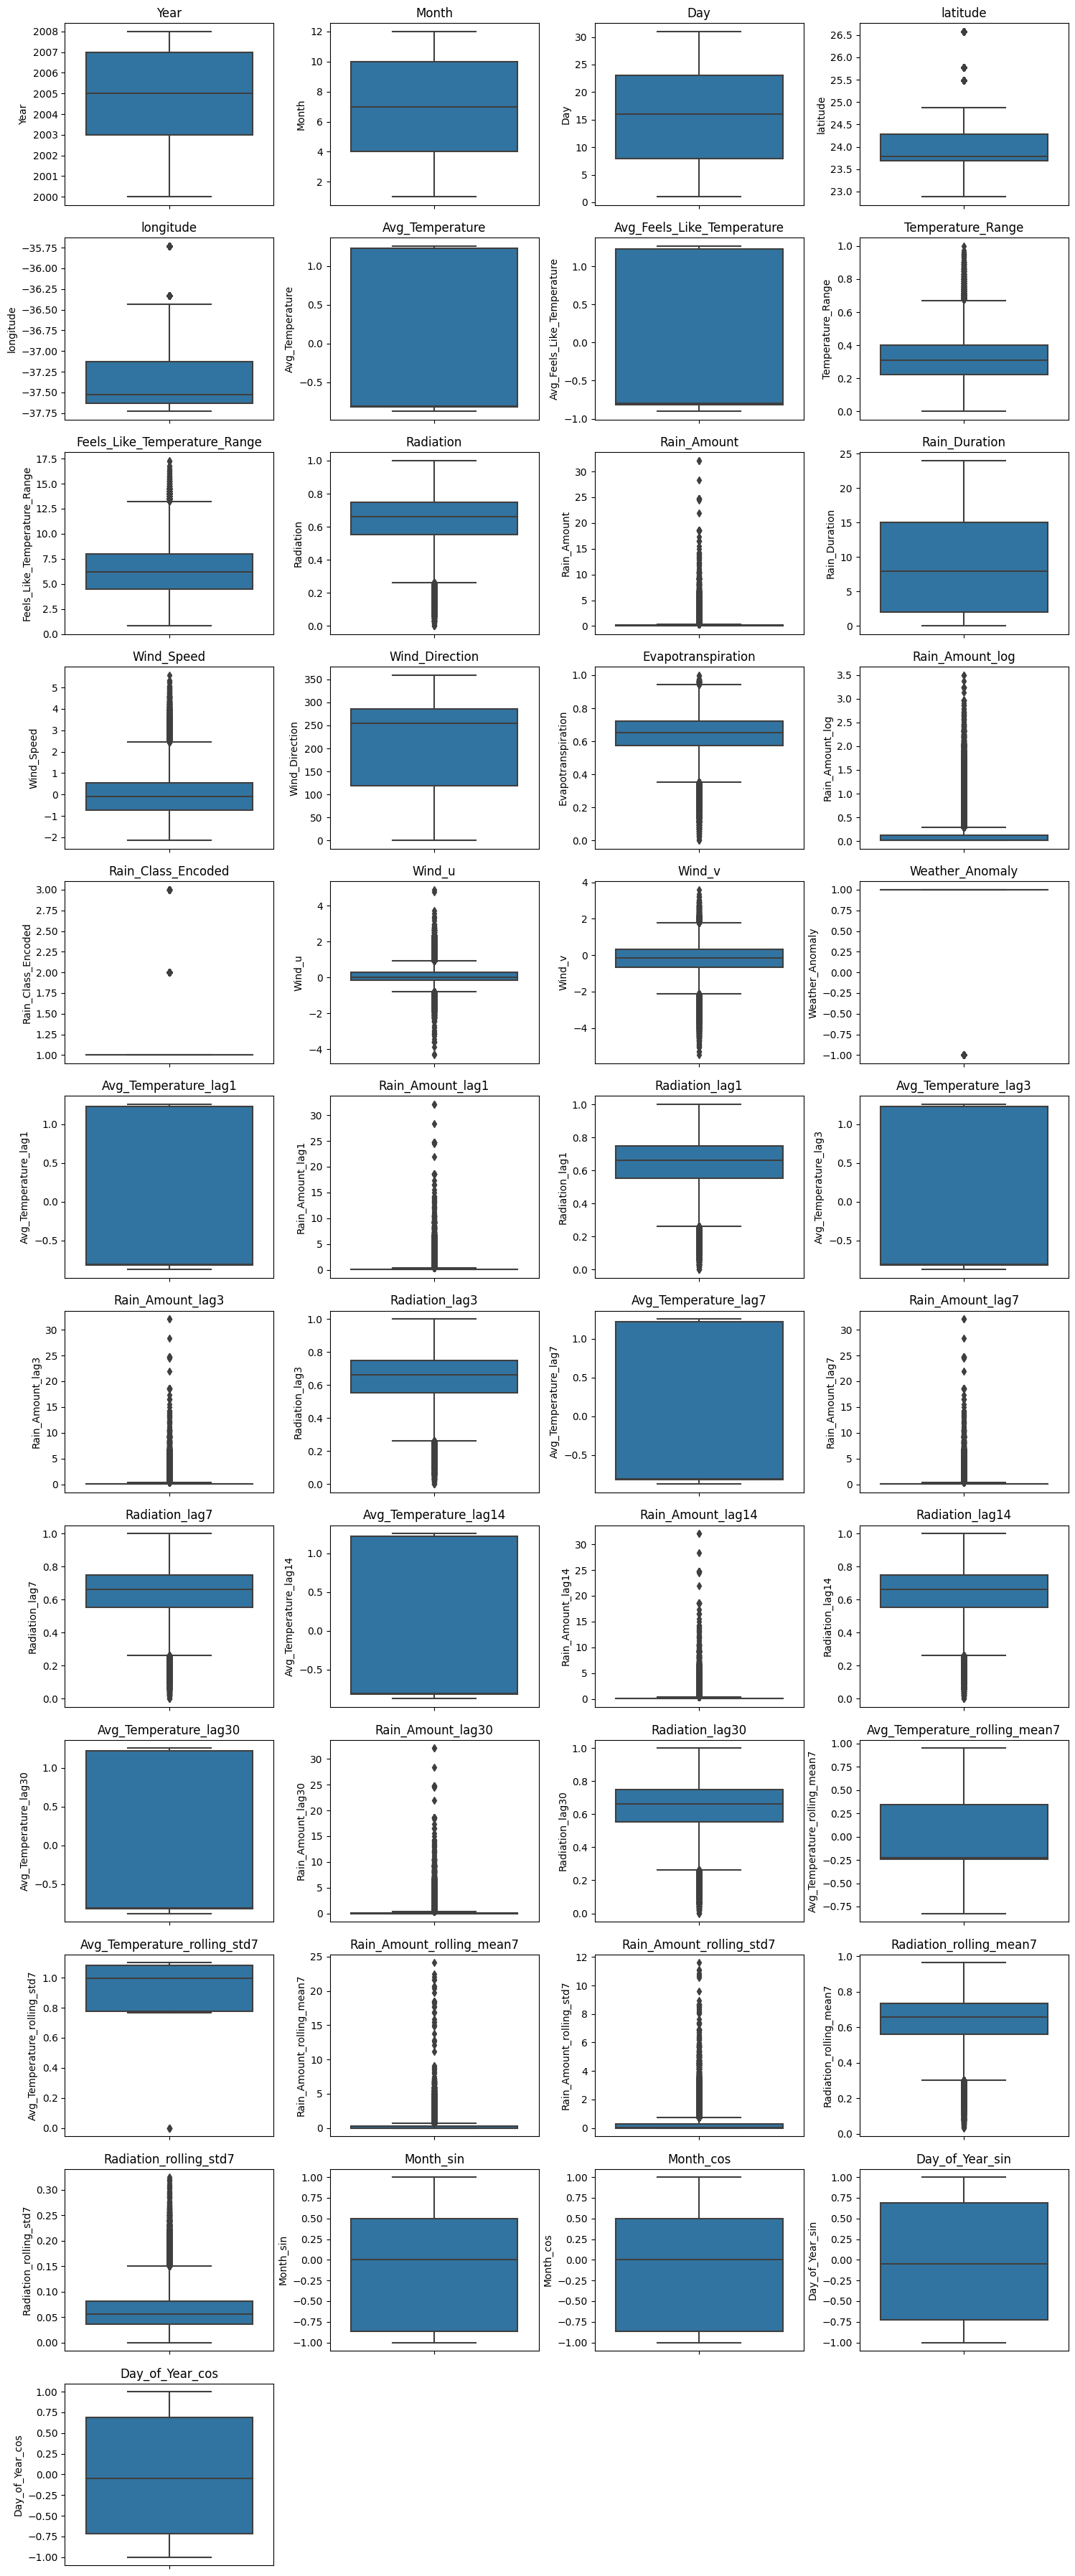

In [22]:
import math

# Detect numeric columns (both int64 and float64)
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Dynamically compute rows and columns
num_cols = len(numeric_cols)
rows = math.ceil(num_cols / 4)  # 4 columns per row

plt.figure(figsize=(15, rows * 3))  # Adjust height dynamically
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 4, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Time Series EDA - Plots**

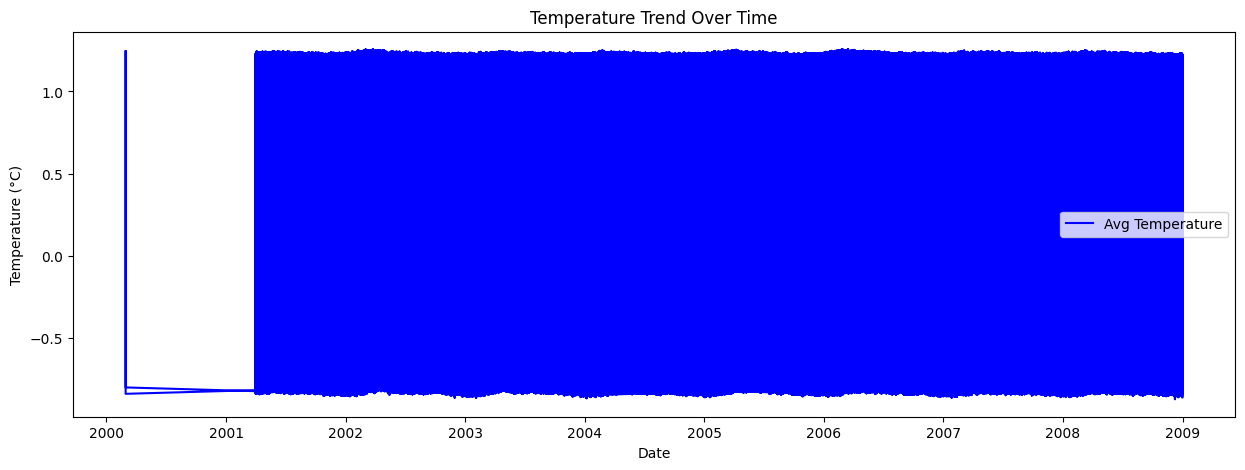

In [23]:
plt.figure(figsize=(15, 5))
plt.plot(data['Date'], data['Avg_Temperature'], label='Avg Temperature', color='blue')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Trend Over Time')
plt.legend()
plt.show()

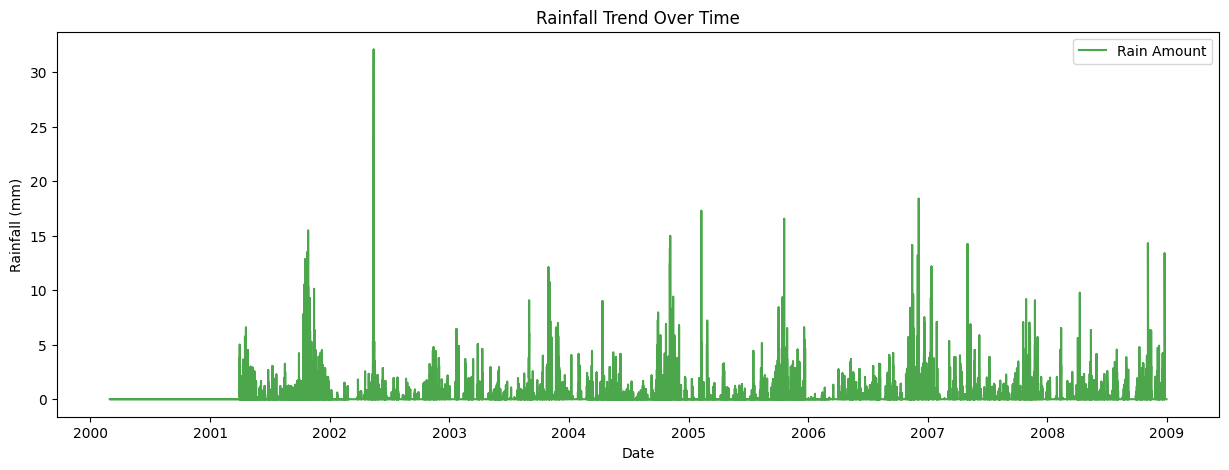

In [24]:
plt.figure(figsize=(15, 5))
plt.plot(data['Date'], data['Rain_Amount'], label='Rain Amount', color='green', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall Trend Over Time')
plt.legend()
plt.show()

In [25]:
data['Rain_Amount_rolling_mean7'] = data['Rain_Amount_rolling_mean7'].clip(upper=100)

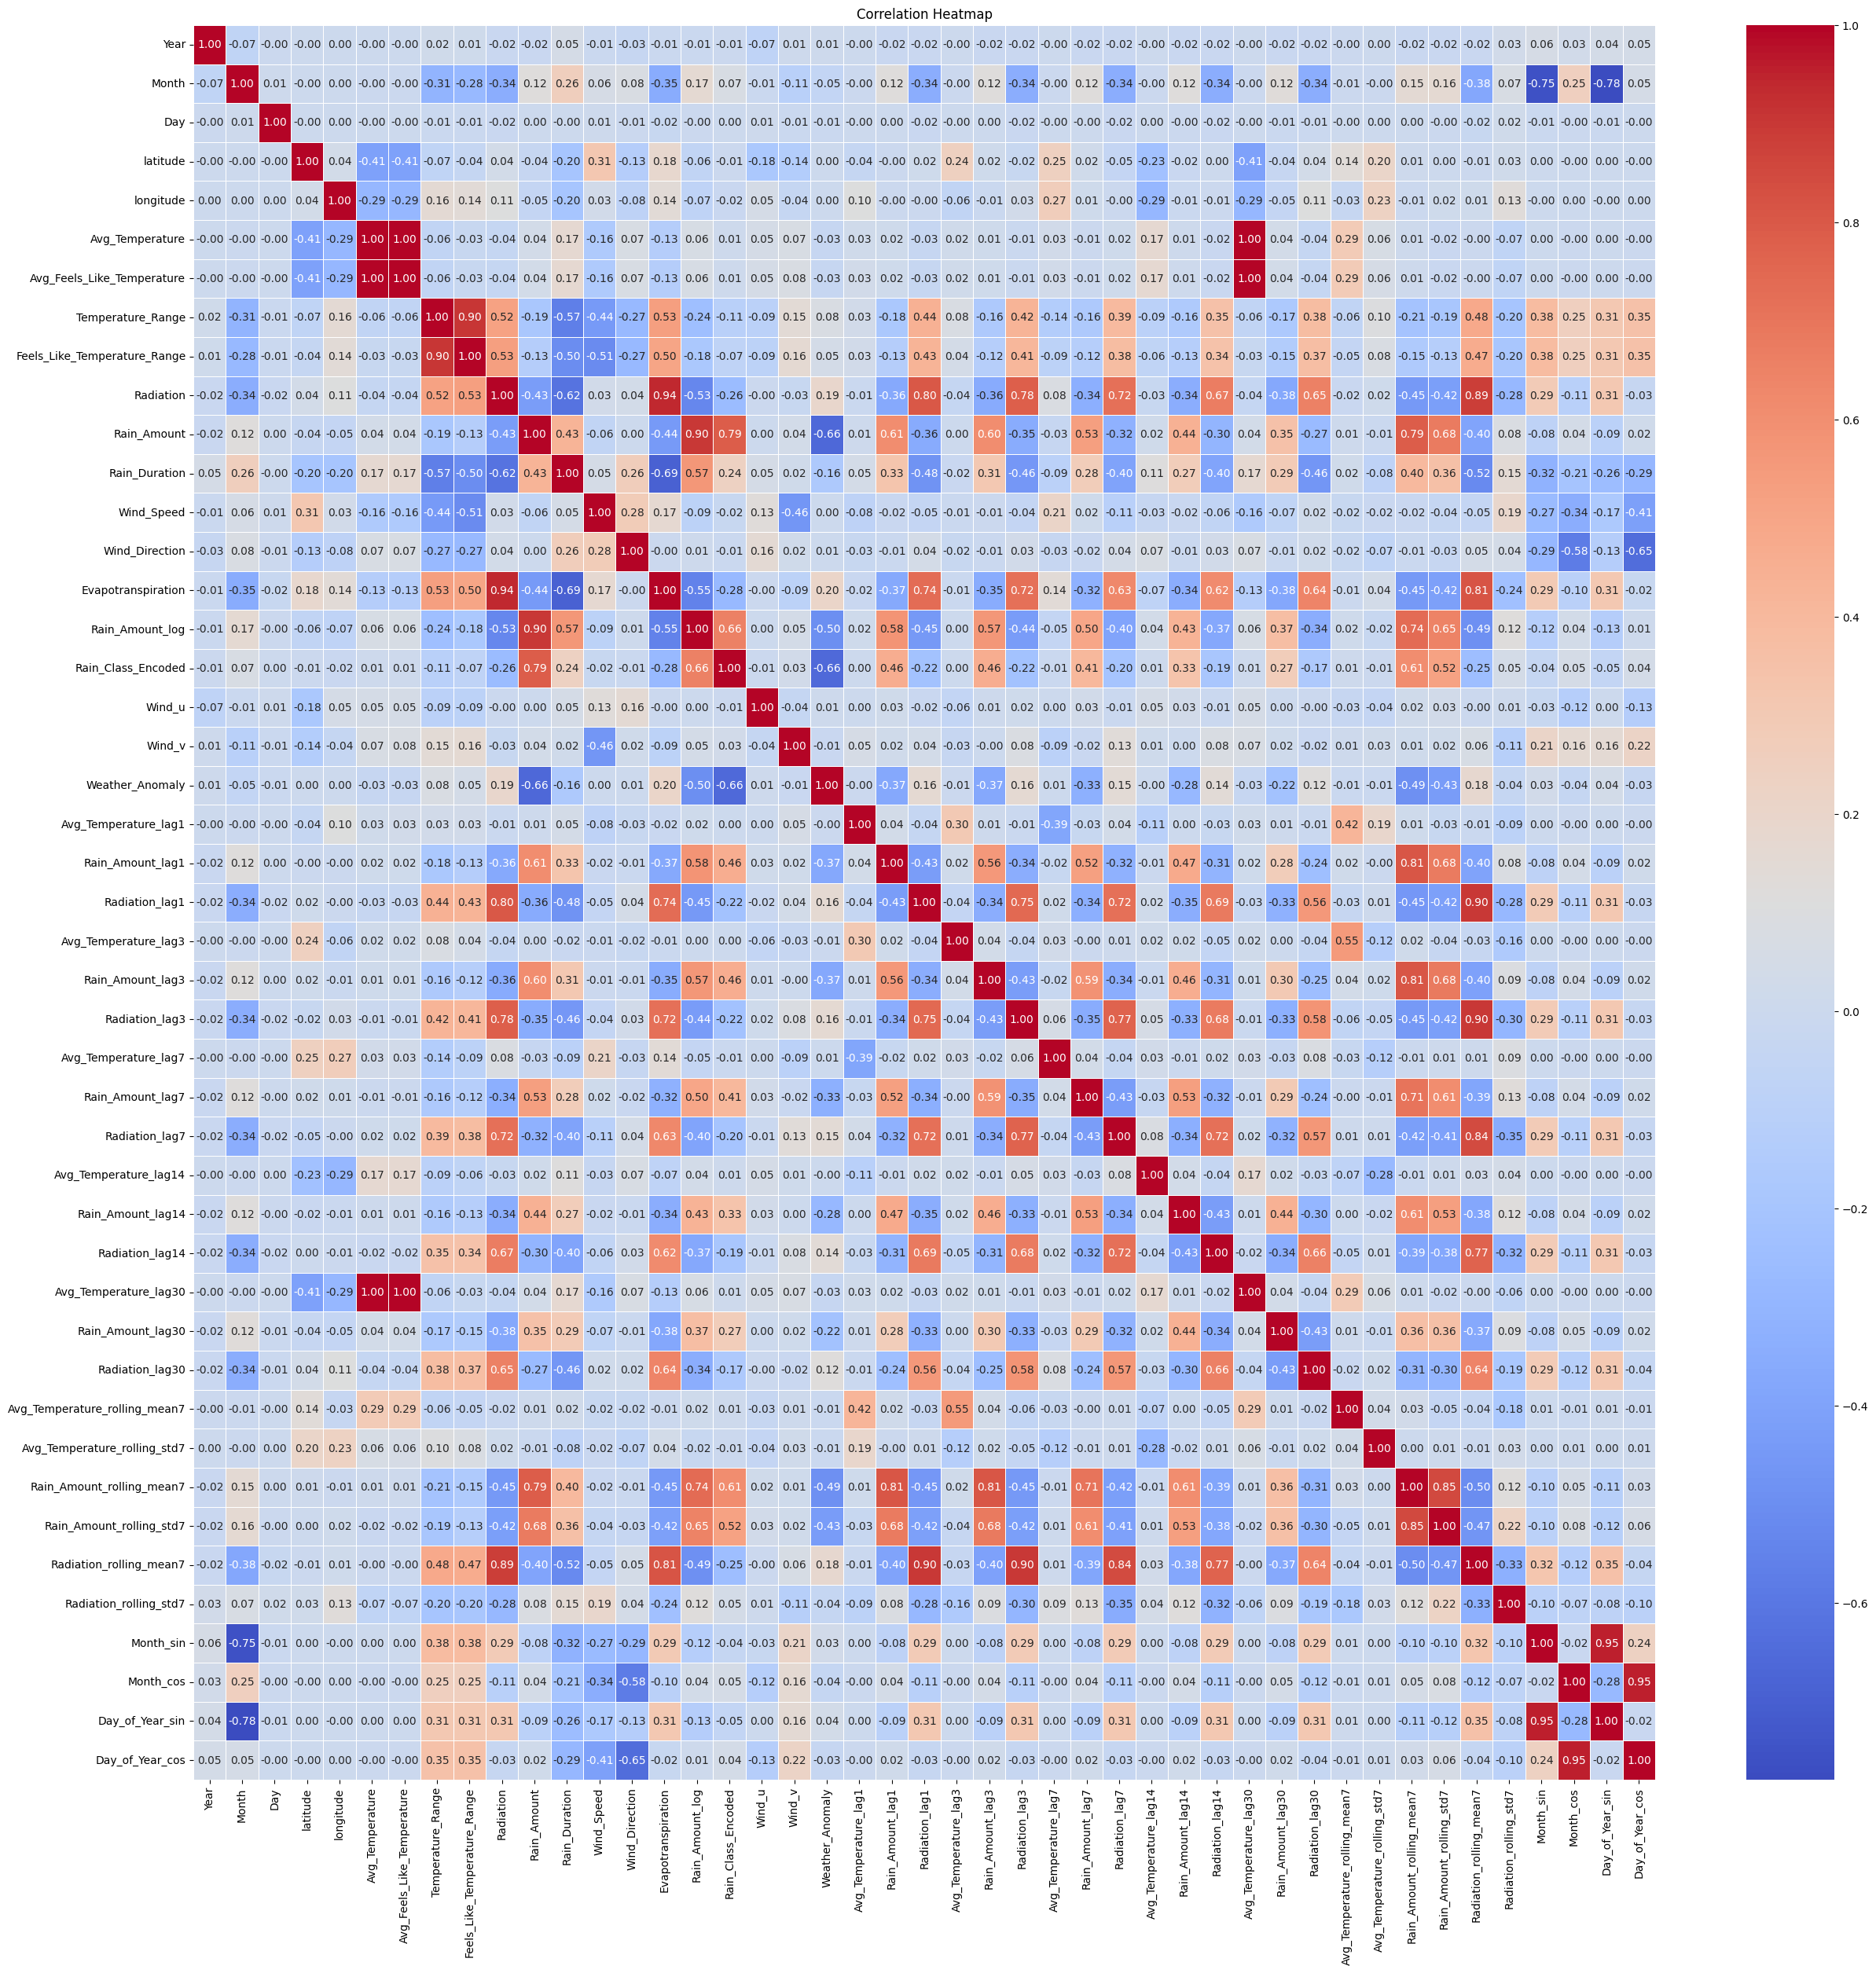

In [26]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(30, 29))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84960 entries, 0 to 84959
Data columns (total 78 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Year                           84960 non-null  int64         
 1   Month                          84960 non-null  int64         
 2   Day                            84960 non-null  int64         
 3   latitude                       84960 non-null  float64       
 4   longitude                      84960 non-null  float64       
 5   Avg_Temperature                84960 non-null  float64       
 6   Avg_Feels_Like_Temperature     84960 non-null  float64       
 7   Temperature_Range              84960 non-null  float64       
 8   Feels_Like_Temperature_Range   84960 non-null  float64       
 9   Radiation                      84960 non-null  float64       
 10  Rain_Amount                    84960 non-null  float64       
 11  Rain_Duration  

In [28]:
print(data.describe()) 

               Year         Month           Day      latitude     longitude  \
count  84960.000000  84960.000000  84960.000000  84960.000000  84960.000000   
mean    2004.609463      6.666667     15.735876     24.003334    -37.266665   
min     2000.000000      1.000000      1.000000     22.880000    -37.729980   
25%     2003.000000      4.000000      8.000000     23.680003    -37.630006   
50%     2005.000000      7.000000     16.000000     23.780002    -37.530000   
75%     2007.000000     10.000000     23.000000     24.280002    -37.130006   
max     2008.000000     12.000000     31.000000     26.580005    -35.729980   
std        2.240346      3.402793      8.802867      0.798622      0.488873   

       Avg_Temperature  Avg_Feels_Like_Temperature  Temperature_Range  \
count     8.496000e+04                8.496000e+04       84960.000000   
mean      1.129249e-16               -8.405078e-17           0.325187   
min      -8.754289e-01               -9.036781e-01           0.000000

In [29]:
data.isna().sum()

Year               0
Month              0
Day                0
latitude           0
longitude          0
                  ..
Day_of_Year        0
Month_sin          0
Month_cos          0
Day_of_Year_sin    0
Day_of_Year_cos    0
Length: 78, dtype: int64

# Data Spliting and Normalization

In [30]:
# Sort data in chronological order
data = data.sort_values(by="Date").reset_index(drop=True)

In [31]:
# Define target and feature columns
target_cols = ["Avg_Temperature", "Radiation", "Rain_Amount", "Wind_Speed", "Wind_Direction"]
feature_cols = [col for col in data.columns if col not in ['Date', 'Year', 'Month', 'Day'] + target_cols]

In [32]:
# Normalize target variables
target_scalers = {col: MinMaxScaler() for col in target_cols}
for col in target_cols:
    data[col] = target_scalers[col].fit_transform(data[[col]])

# Create time series sequences
def create_sequences(data, target_cols, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i : i + seq_length][feature_cols].values)
        y.append(data.iloc[i + seq_length][target_cols].values)
    return np.array(X), np.array(y)


In [33]:
# Split into training and validation sets
split_ratio = 0.8
split_index = int(len(data) * split_ratio)

# Fill NaN for lagged and rolling features
data.bfill(inplace=True)  # Backward fill
data.ffill(inplace=True)  # Forward fill

# Now create sequences
train_X, train_y = create_sequences(data.iloc[:split_index], target_cols)
val_X, val_y = create_sequences(data.iloc[split_index:], target_cols)

train_X = train_X.astype(np.float32)
train_y = train_y.astype(np.float32)
val_X = val_X.astype(np.float32)
val_y = val_y.astype(np.float32)

print("NaN in train_X after fix:", np.isnan(train_X).sum())  # Should be 0 now!


NaN in train_X after fix: 0


In [34]:
print("NaN in train_X:", np.isnan(train_X).sum())
print("NaN in train_y:", np.isnan(train_y).sum())
print("NaN in val_X:", np.isnan(val_X).sum())
print("NaN in val_y:", np.isnan(val_y).sum())

NaN in train_X: 0
NaN in train_y: 0
NaN in val_X: 0
NaN in val_y: 0


# LSTM Data Preparation

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

# Function to build model with hyperparameters
def build_lstm(input_shape, output_dim, lstm_units=100, dropout_rate=0.2, learning_rate=0.0001):
    model = Sequential([
        Input(shape=input_shape),  
        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units // 2),
        Dropout(dropout_rate),
        Dense(output_dim)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Define hyperparameter grid
lstm_units_list = [50]  
dropout_rate_list = [0.2]  
learning_rate_list = [0.0001, 0.001]  

best_score = float('inf')
best_params = {}
best_model = None  # To store the best model

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Grid search
for lstm_units in lstm_units_list:
    for dropout_rate in dropout_rate_list:
        for learning_rate in learning_rate_list:
            print(f"\n Training with: units={lstm_units}, dropout={dropout_rate}, learning_rate={learning_rate}")
            
            # Build model
            model = build_lstm((train_X.shape[1], train_X.shape[2]), len(target_cols),
                               lstm_units=lstm_units, dropout_rate=dropout_rate, learning_rate=learning_rate)
            
            # Train model
            history = model.fit(
                train_X, train_y, validation_data=(val_X, val_y), 
                epochs=10, batch_size=32, callbacks=[early_stopping], verbose=1
            )
            
            # Evaluate model
            val_loss = min(history.history['val_loss'])  # Best validation loss from early stopping
            
            print(f"Validation Loss: {val_loss:.4f}")
            
            if val_loss < best_score:
                best_score = val_loss
                best_params = {'lstm_units': lstm_units, 'dropout_rate': dropout_rate, 'learning_rate': learning_rate}
                best_model = model  # Save the best model
            
print(f"\n Best Hyperparameters: {best_params}")


 Training with: units=50, dropout=0.2, learning_rate=0.0001
Epoch 1/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - loss: 0.1164 - val_loss: 0.0549
Epoch 2/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0624 - val_loss: 0.0489
Epoch 3/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0537 - val_loss: 0.0433
Epoch 4/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0469 - val_loss: 0.0395
Epoch 5/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0427 - val_loss: 0.0368
Epoch 6/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0396 - val_loss: 0.0350
Epoch 7/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 50s 24ms/step - loss: 0.0379 - val_loss: 0.0338
Epoch 8/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0363 - val_loss: 0.0326
Epoch 9/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0346 - val_loss: 0.0312
Epoch 10/10
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.0328 - val_loss: 0.0321
Validation Loss: 0.0312

 Training wit

In [37]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train final model using best hyperparameters
best_model = build_lstm(
    input_shape=(train_X.shape[1], train_X.shape[2]), 
    output_dim=len(target_cols),
    lstm_units=best_params['lstm_units'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with early stopping
history = best_model.fit(train_X, train_y, validation_data=(val_X, val_y),
                         epochs=50, batch_size=16, callbacks=[early_stopping])


Epoch 1/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 96s 22ms/step - loss: 0.0596 - val_loss: 0.0318
Epoch 2/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 92s 22ms/step - loss: 0.0322 - val_loss: 0.0274
Epoch 3/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 94s 22ms/step - loss: 0.0267 - val_loss: 0.0251
Epoch 4/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 96s 23ms/step - loss: 0.0235 - val_loss: 0.0219
Epoch 5/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 95s 22ms/step - loss: 0.0213 - val_loss: 0.0206
Epoch 6/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 96s 23ms/step - loss: 0.0200 - val_loss: 0.0187
Epoch 7/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 98s 23ms/step - loss: 0.0192 - val_loss: 0.0180
Epoch 8/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 97s 23ms/step - loss: 0.0184 - val_loss: 0.0176
Epoch 9/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 97s 23ms/step - loss: 0.0177 - val_loss: 0.0171
Epoch 10/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 97s 23ms/step - loss: 0.0171 - val_loss: 0.0163
Epoch 11/50
4247/4247 ━━━━━━━━━━━━━━━━━━━━ 97s 23ms/step - loss: 0.0168 - val_loss: 0.0170
Epoch 12

In [38]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8))

val_predictions = best_model.predict(val_X)
val_smape = smape(val_y, val_predictions)
print(f"Validation sMAPE: {val_smape:.2f}%")

531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
Validation sMAPE: 53.83%


In [39]:
import numpy as np
import pandas as pd
from IPython.display import display, FileLink

# Load test data
test_data = pd.read_csv('/kaggle/input/data-crunch-round-1/test.csv')

# Use the last sequence from training data for predictions
last_sequence = np.array(data[feature_cols].values[-30:], dtype=np.float32).reshape(1, 30, len(feature_cols))

# Generate predictions
future_predictions = []

for _ in range(len(test_data)):  
    pred = model.predict(last_sequence)[0]  # Get next predicted step

    # Expand prediction to match feature shape
    pred_expanded = np.zeros((1, 1, last_sequence.shape[2]))  
    pred_expanded[:, :, :pred.shape[0]] = pred  

    future_predictions.append(pred)

    # Update sliding window
    last_sequence = np.concatenate((last_sequence[:, 1:, :], pred_expanded), axis=1)

# Convert predictions back to original scale
future_predictions = np.array(future_predictions)

for i, col in enumerate(target_cols):
    future_predictions[:, i] = target_scalers[col].inverse_transform(
        future_predictions[:, i].reshape(-1, 1)
    ).flatten()

# Create submission file
submission = pd.DataFrame({'ID': test_data['ID']})  

# Assign predicted values
for i, col in enumerate(target_cols):
    submission[col] = future_predictions[:, i]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━

In [40]:

# Save submission file
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission file saved: {submission_path}")

# Display download link for Kaggle
display(FileLink(submission_path))

Submission file saved: submission.csv


/kaggle/working/submission.csv

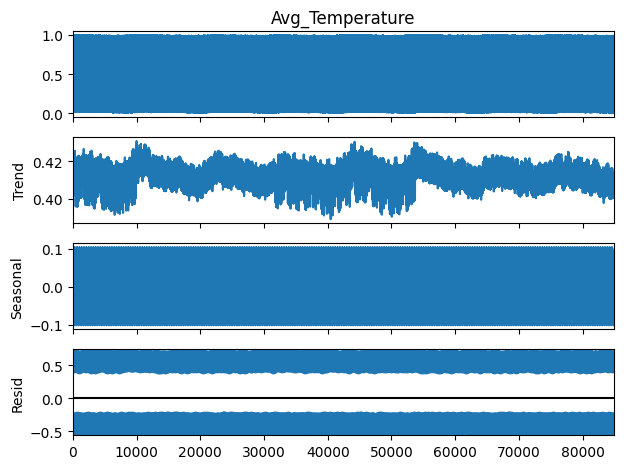

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series (choose a column to analyze, e.g., 'Avg_Temperature')
temperature_series = data['Avg_Temperature']
decomposition = seasonal_decompose(temperature_series, model='additive', period=365)  # Daily seasonality

# Plot the decomposition
decomposition.plot()
plt.show()


<Figure size 1200x600 with 0 Axes>

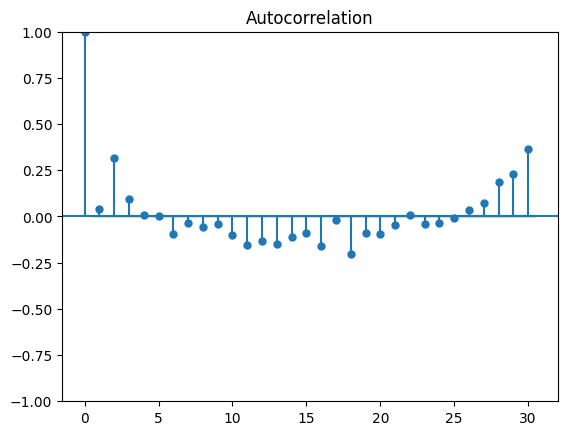

<Figure size 1200x600 with 0 Axes>

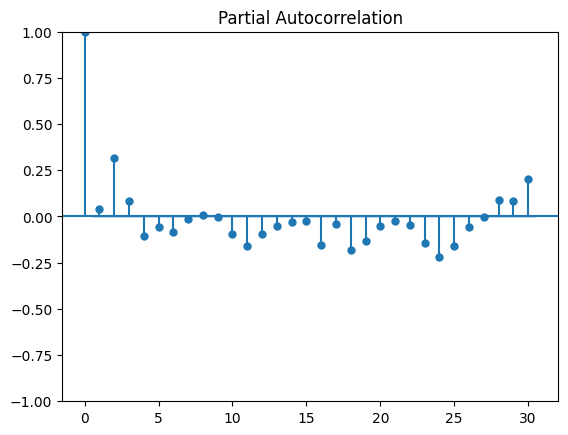

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for a target variable
plt.figure(figsize=(12, 6))
plot_acf(temperature_series, lags=30)  # ACF for 30 lags
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(temperature_series, lags=30)  # PACF for 30 lags
plt.show()


In [43]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the 'Avg_Temperature' column
adf_result = adfuller(temperature_series)

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

# Interpretation of the result
if adf_result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary. Differencing might be needed.")


ADF Statistic: -59.263488442081126
p-value: 0.0
Critical Values: {'1%': -3.4304270313301286, '5%': -2.8615740465743107, '10%': -2.566788121811769}
The series is stationary.


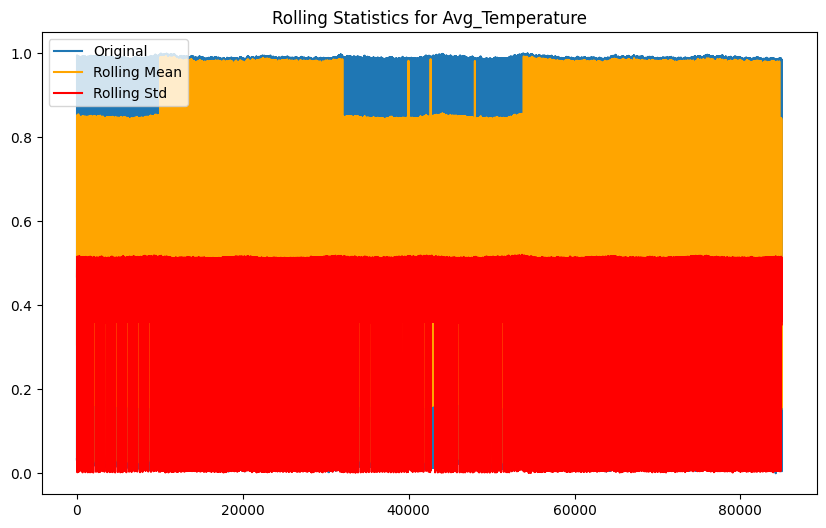

In [44]:
# Moving Average and Standard Deviation
rolling_mean = temperature_series.rolling(window=7).mean()  # 7-day rolling mean
rolling_std = temperature_series.rolling(window=7).std()    # 7-day rolling standard deviation

# Plot the rolling statistics
plt.figure(figsize=(10, 6))
plt.plot(temperature_series, label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='orange')
plt.plot(rolling_std, label='Rolling Std', color='red')
plt.legend(loc='best')
plt.title('Rolling Statistics for Avg_Temperature')
plt.show()
